In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp
import importlib.resources
import pathlib

## configure path
try:
    irdb_path = str(pathlib.Path(importlib.resources.files('irdb')).parent)
except ModuleNotFoundError:
    irdb_path = "/Users/yashvi/Desktop/ZShooter/irdb/"

sim.rc.__config__["!SIM.file.local_packages_path"] = irdb_path
sim.rc.__config__["!SIM.file.search_path"].append(irdb_path)
## configure log level
sim.utils.set_console_log_level("DEBUG")

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



**NOTE: This notebook is meant to be a high-level overview of the ScopeSim workflow.**

**NOTE: The z_order information in official ScopeSim documentation is not all correct. The sequence of effects is determined by the placement in yaml configs, NOT the z_order value. The type of effects and their corresponding numbers are also listed incorrectly in the docstrings, so refer here or the code directly.**

## Optical train setup
Here we are loading ZShooter_v2 configuration files (`UserCommands()`).

During setup of an optical train (`OpticalTrain()`), all effects are read from the yamls and processed by the `OpticsManager()`.
- `FOVManager()` is called with fov_setup_effects (z_order 2xx). This step applies fov_setup_effects sequentially to precompute all FoVs (spatio-spectral volumes) that are uniquely defined. For example, an aperture effect that applies multiple slits creates one FoV per slit from the input `FovVolumeList()`. These FoVs do not have any hdu data attached to them yet.
- `ImagePlane()` objects are initialized from image plane headers.
- `DetectorManager()` is called with detector_setup_effects (z_order 4xx, usually `DetectorList()`) to create `Detector()` object instances for all defined detectors in yaml.

In [3]:
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
zs = sim.OpticalTrain(cmd)

astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-05-16T10:21:53.856.
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - Setting obstime to midnight of the same day. New UTC time is 2026-05-16T10:21:53.856.
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.effects.psfs.analytical - using seeing and natural scale for FWHM
astar.scopesim.effects.psfs.analytical - Using !OBS.alt to determine zenith angle.
astar.scopesim.effects.ter_curves - Loading dichroic bgr-yjhk from dichroics/TER_dichroic_bgr-yjhk.dat
astar.scopesim.effects.ter_curves - Loading dichroic b-gr from dichroics/TER_dichroic_b-gr.dat

## Create a source to observe

In [7]:
# star
star = sim_tp.star(filter_name='V', amplitude=10*u.ABmag)

## The observe() method
In the `OpticalTrain.observe()` function, the following steps are executed:
- source effects (z_order 5xx, e.g. 1D transmission) are applied to the prepared source
- FoVs (created during init) are iterated through, the source data that belongs to an FoV is extracted and attached to it, and fov effects (z_order 6xx) are applied sequentially. The sequence is determined by the placement in yaml configs (NOT the z_order value, the official ScopeSim documentation is not all correct).
- The hdu data from the modified FoVs is put into the correct `ImagePlane()` object based on the FoV's metadata.
- Lastly, any image plane effects are applied (z_order 7xx)

In [9]:
zs.observe(star)

astar.scopesim.optics.fov_manager - Generating initial fovs_list.
astar.scopesim.effects.ter_curves - Executing dichroic_tree, FoV setup
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 0
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 1
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 2
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 3
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 4
astar.scopesim.effects.ter_curves - Created 1 FoVs for aperture_id 5
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 0 -> SlitWheel: "<empty> : [ubvis_one_arcsec]", volumes: 1
astar.scopesim.effects.apertures - Executing ubvis_one_arcsec, FoV setup
astar.scopesim.effects.selector_wheel - Applying effect for aperture_id: 1 -> SlitWheel: "<empty> : [ubvis_one_arcsec]", volumes: 1
astar.scopesim.effects.apertures - Executing ubvis_one_arcsec, FoV setup
astar.scopesim.effects.selector_wheel -

 FOVs:   0%|          | 0/120 [00:00<?, ?it/s]

astar.scopesim.optics.fov - 7 fields in FOV



 FOV effects:   0%|          | 0/5 [00:00<?, ?it/s]

astar.scopesim.effects.psfs.psf_base - Executing seeing_psf, convolution
astar.scopesim.effects.psfs.psf_base - PSF convolution start
astar.scopesim.effects.psfs.psf_base - PSF convolution done


...


 FOV effects:  40%|████      | 2/5 [00:00<00:01,  2.24it/s]

astar.scopesim.effects.ter_curves - Executing dichroic_tree, observe
astar.scopesim.effects.spectral_trace_list - trace_list_analytical applied to FieldOfView3D
astar.scopesim.effects.spectral_trace_list_utils - Mapping k_39
astar.scopesim.effects.spectral_trace_list - trace_list_analytical done



 FOV effects: 100%|██████████| 5/5 [00:01<00:00,  4.95it/s]

astar.scopesim.optics.image_plane - No BUNIT found in added HDU.



 FOVs: 100%|██████████| 120/120 [03:16<00:00,  1.63s/it]


## Readout
Lastly, `OpticalTrain.readout()` maps the image planes to detector hdu using the header and meta information.

For each `Detector()` object (managed by `DetectorManager()`), the corresponding `ImagePlane()` is found and the hdu data is put into the correct location in the detector hdu, along with the application of any detector_effects (z_order 8xx) and detector_array_effects (z_order 9xx). Lastly, fits header effects are applied (z_order 10xx) and the hdu is returned in a list (or can be saved to a file directly).

In [10]:
hdus = zs.readout()

astar.scopesim.optics.optical_train - exptime: None given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - dit: 10 given in kwargs, put in !OBS
astar.scopesim.optics.optical_train - ndit: 1 given in kwargs, put in !OBS
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 10 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.effects.selector_wheel - Since passed object is a Detector, selector_key by default is the ID of the Detector object.
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...
astar.scopesim.effects.electronic - ExposureIntegration.: DIT = 10 s, NDIT = 1
astar.scopesim.effects.selector_wheel - Since passed object is a

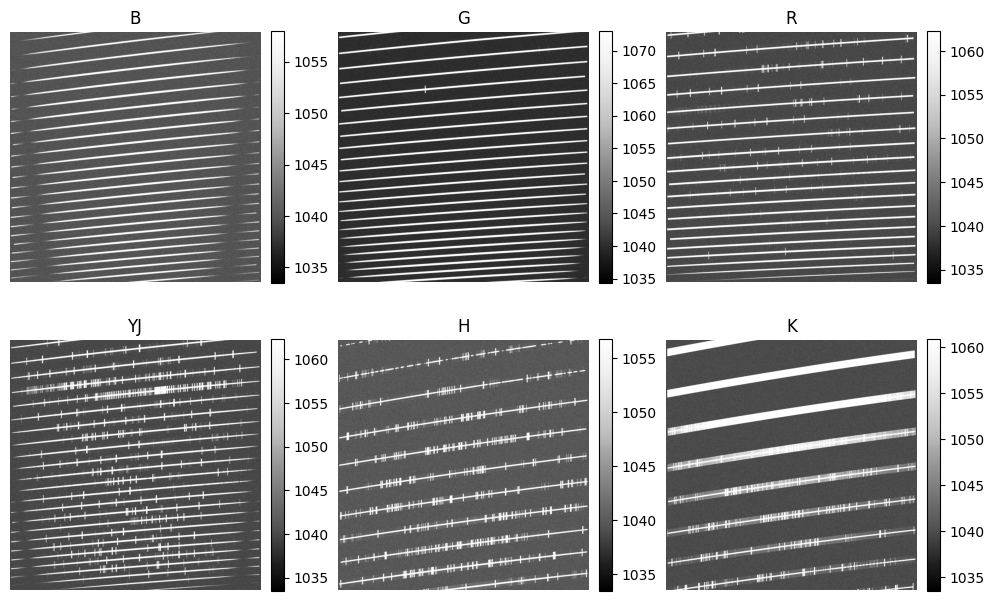

In [12]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
i = 0
for ax, imhdu in zip(axes.flat, hdus):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    i += 1

plt.subplots_adjust(wspace=0.0, hspace=0.0)